<center><h1 style="background-color: #C6F3CD; border-radius: 10px; color: #FFFFFF; padding: 5px;">
Naive Seasonal Model

</h1><center/>

**Link to the article** :  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1) Generating the Synthetic Data

In [5]:
# 1. Generate synthetic monthly data (3 years of data)
np.random.seed(42)
dates = pd.date_range(start='2020-01-01', periods=36, freq='ME')

# Create a series with seasonality (sine wave), a slight trend, and some noise
seasonality = np.sin(np.arange(36) * (2 * np.pi / 12)) * 50
trend = np.arange(36) * 2
noise = np.random.normal(0, 5, 36)
sales = 100 + seasonality + trend + noise

df = pd.DataFrame({'Date': dates, 'Sales': sales}).set_index('Date')
df.head()

,Sales
Date,
2020-01-31,102.483571
2020-02-29,126.308678
2020-03-31,150.539713
2020-04-30,163.615149
2020-05-31,150.130503


## 2) The Train / Test Split

In [6]:
# 2. Train/Test Split: Train (first 2 years) / Test (Last year)
train = df.iloc[:-12]
test = df.iloc[-12:]

## 3) Applying the Seasonal Naive Model

In [7]:
# 3. Apply the Seasonal Naive Model (m = 12)
# The forecast for the next 12 months is exactly the last 12 months of the Train set
m = 12
forecast = train.iloc[-m:].copy()
forecast.index = test.index # Align dates with the test set
forecast.columns = ['Naive_Forecast']

## 4) Visualizing the Results

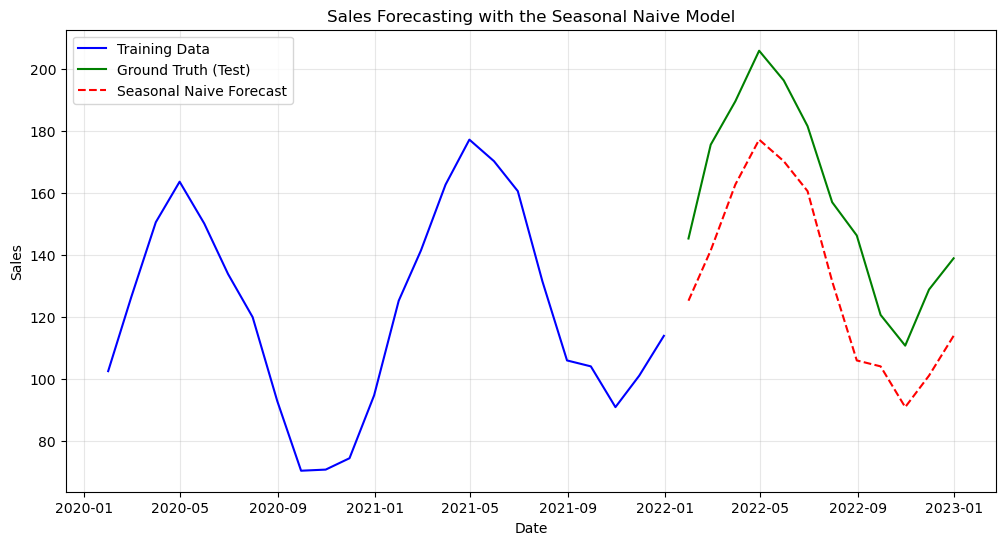

In [8]:
# 4. Visualize the results
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Sales'], label='Training Data', color='blue')
plt.plot(test.index, test['Sales'], label='Ground Truth (Test)', color='green')
plt.plot(forecast.index, forecast['Naive_Forecast'], label='Seasonal Naive Forecast', 
         color='red', linestyle='--')

plt.title('Sales Forecasting with the Seasonal Naive Model')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5) Evaluating the Error MAE and MAPE

In [9]:
mae = np.mean(np.abs(test['Sales'] - forecast['Naive_Forecast']))
print(f"The Mean Absolute Error (MAE) of the naive model is: {mae:.2f}")

The Mean Absolute Error (MAE) of the naive model is: 25.99


In [10]:
mape = np.mean(np.abs((test['Sales'] - forecast['Naive_Forecast']) / test['Sales'])) * 100
print(f"The Mean Absolute Percentage Error (MAPE) is: {mape:.2f}%")

The Mean Absolute Percentage Error (MAPE) is: 16.77%
